In [156]:
import pandas as pd ## analysis
import numpy as np ## comptutational ability
import seaborn as sns 
import matplotlib.pyplot as plt  ## visualization
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [157]:
df=pd.read_csv("/kaggle/input/customer-segmentation/marketing_campaign.csv",sep="\t")

In [158]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [159]:
df.shape

(2240, 29)

In [160]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [161]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
plt.rcParams['figure.figsize'] = (15, 6)

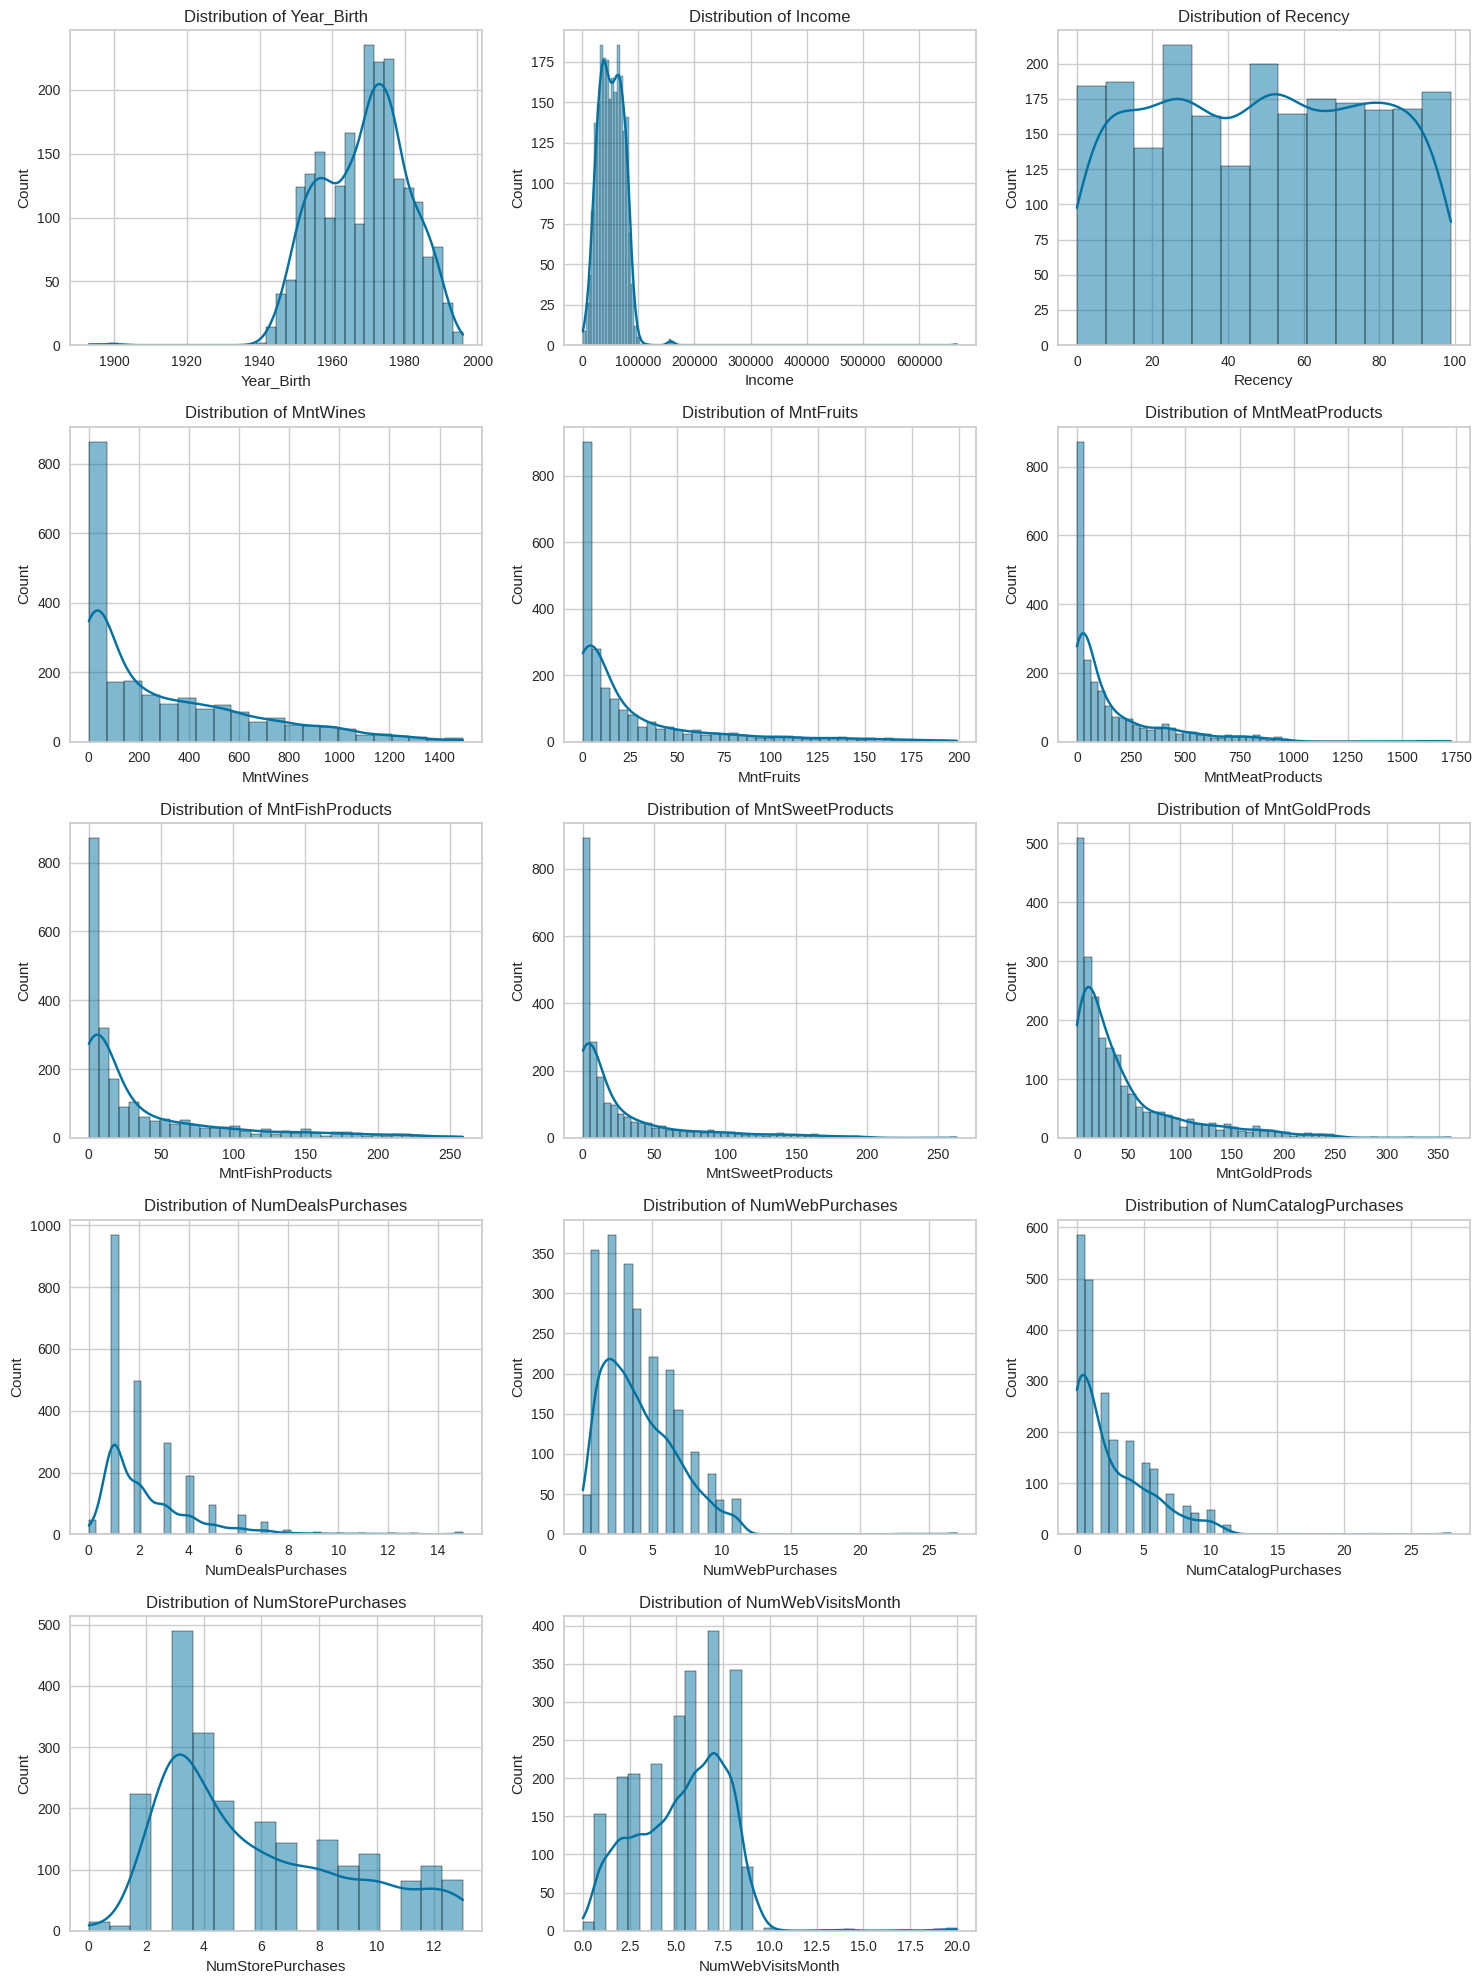

In [162]:
numerical_cols = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'MntFruits', 
                  'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 
                  'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 
                  'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
categorical_cols = ['Education', 'Marital_Status', 'Response', 'AcceptedCmp1', 
                    'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']


n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

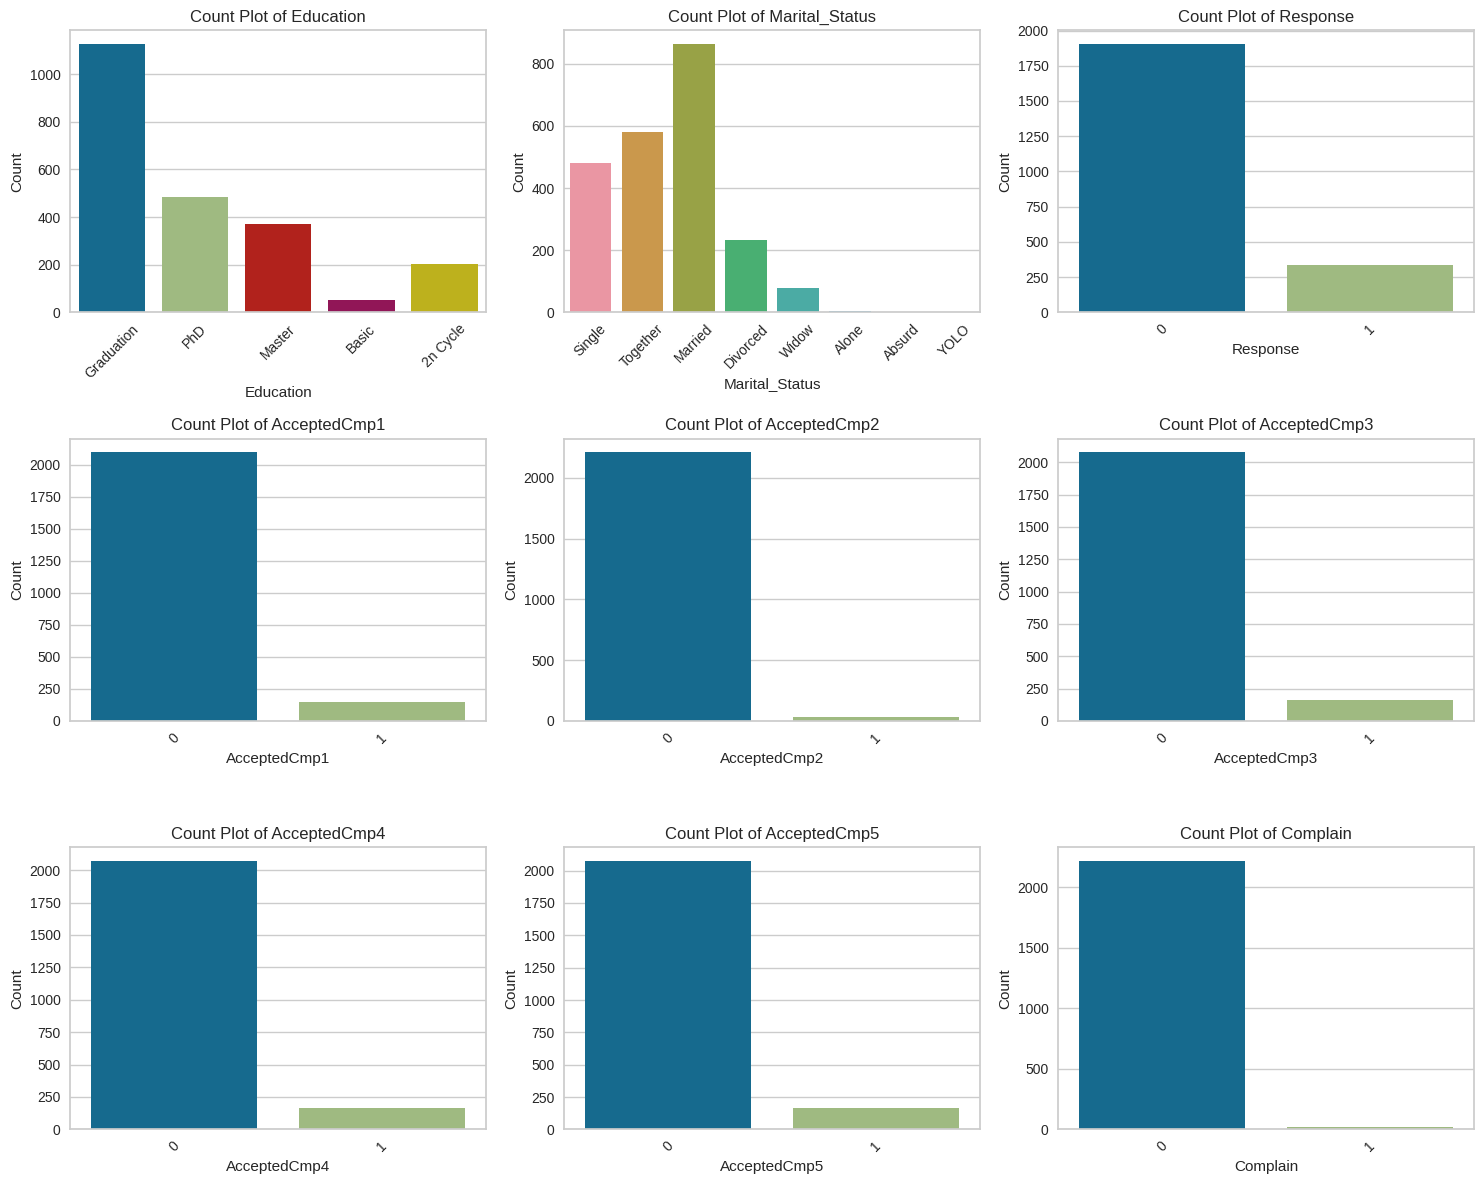

In [163]:
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

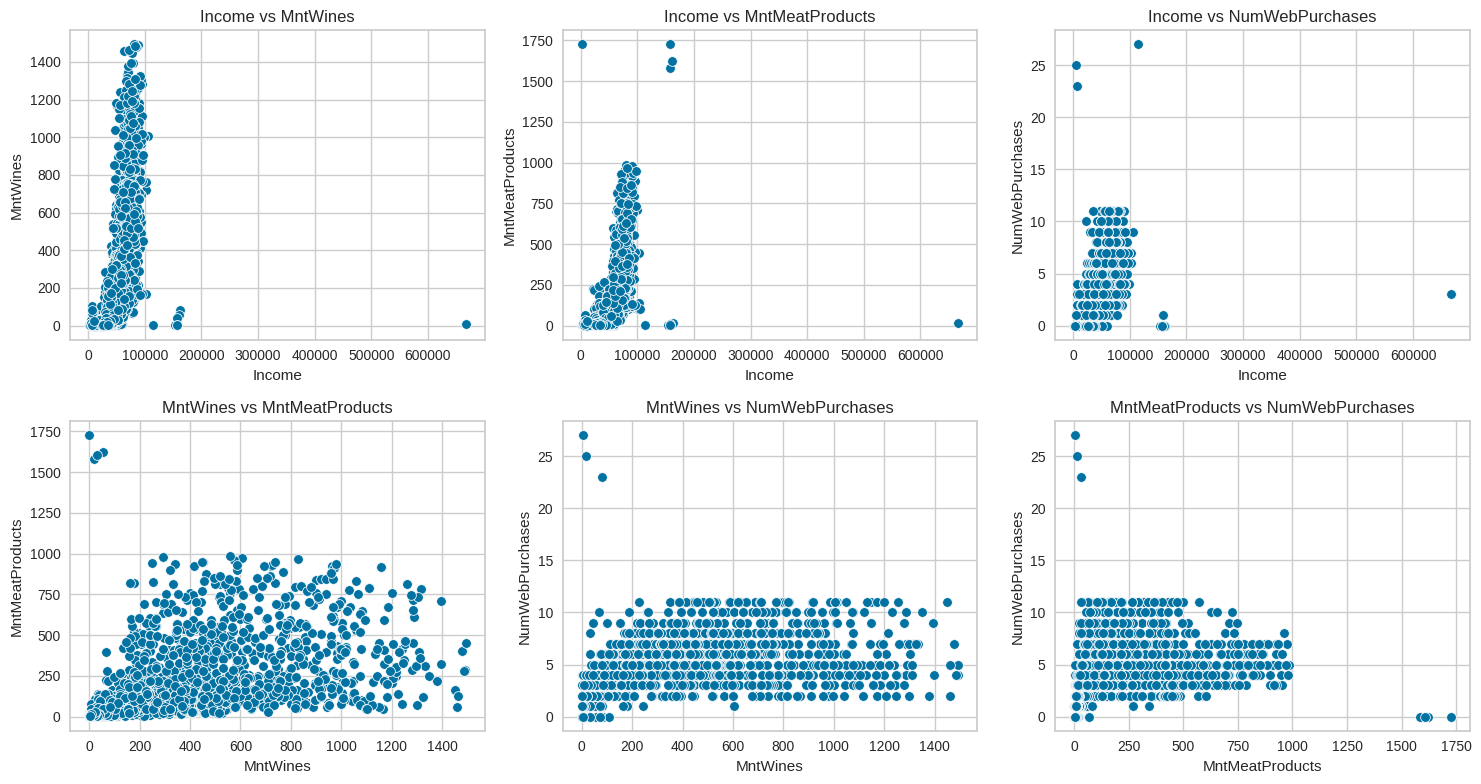

In [164]:
selected_num_cols = ['Income', 'MntWines', 'MntMeatProducts', 'NumWebPurchases']
n_pairs = len(selected_num_cols) * (len(selected_num_cols) - 1) // 2
n_cols = 3
n_rows = (n_pairs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
pair_idx = 0
for i, col1 in enumerate(selected_num_cols):
    for col2 in selected_num_cols[i + 1:]:
        sns.scatterplot(x=col1, y=col2, data=df, ax=axes[pair_idx])
        axes[pair_idx].set_title(f'{col1} vs {col2}')
        axes[pair_idx].set_xlabel(col1)
        axes[pair_idx].set_ylabel(col2)
        pair_idx += 1
for j in range(pair_idx, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

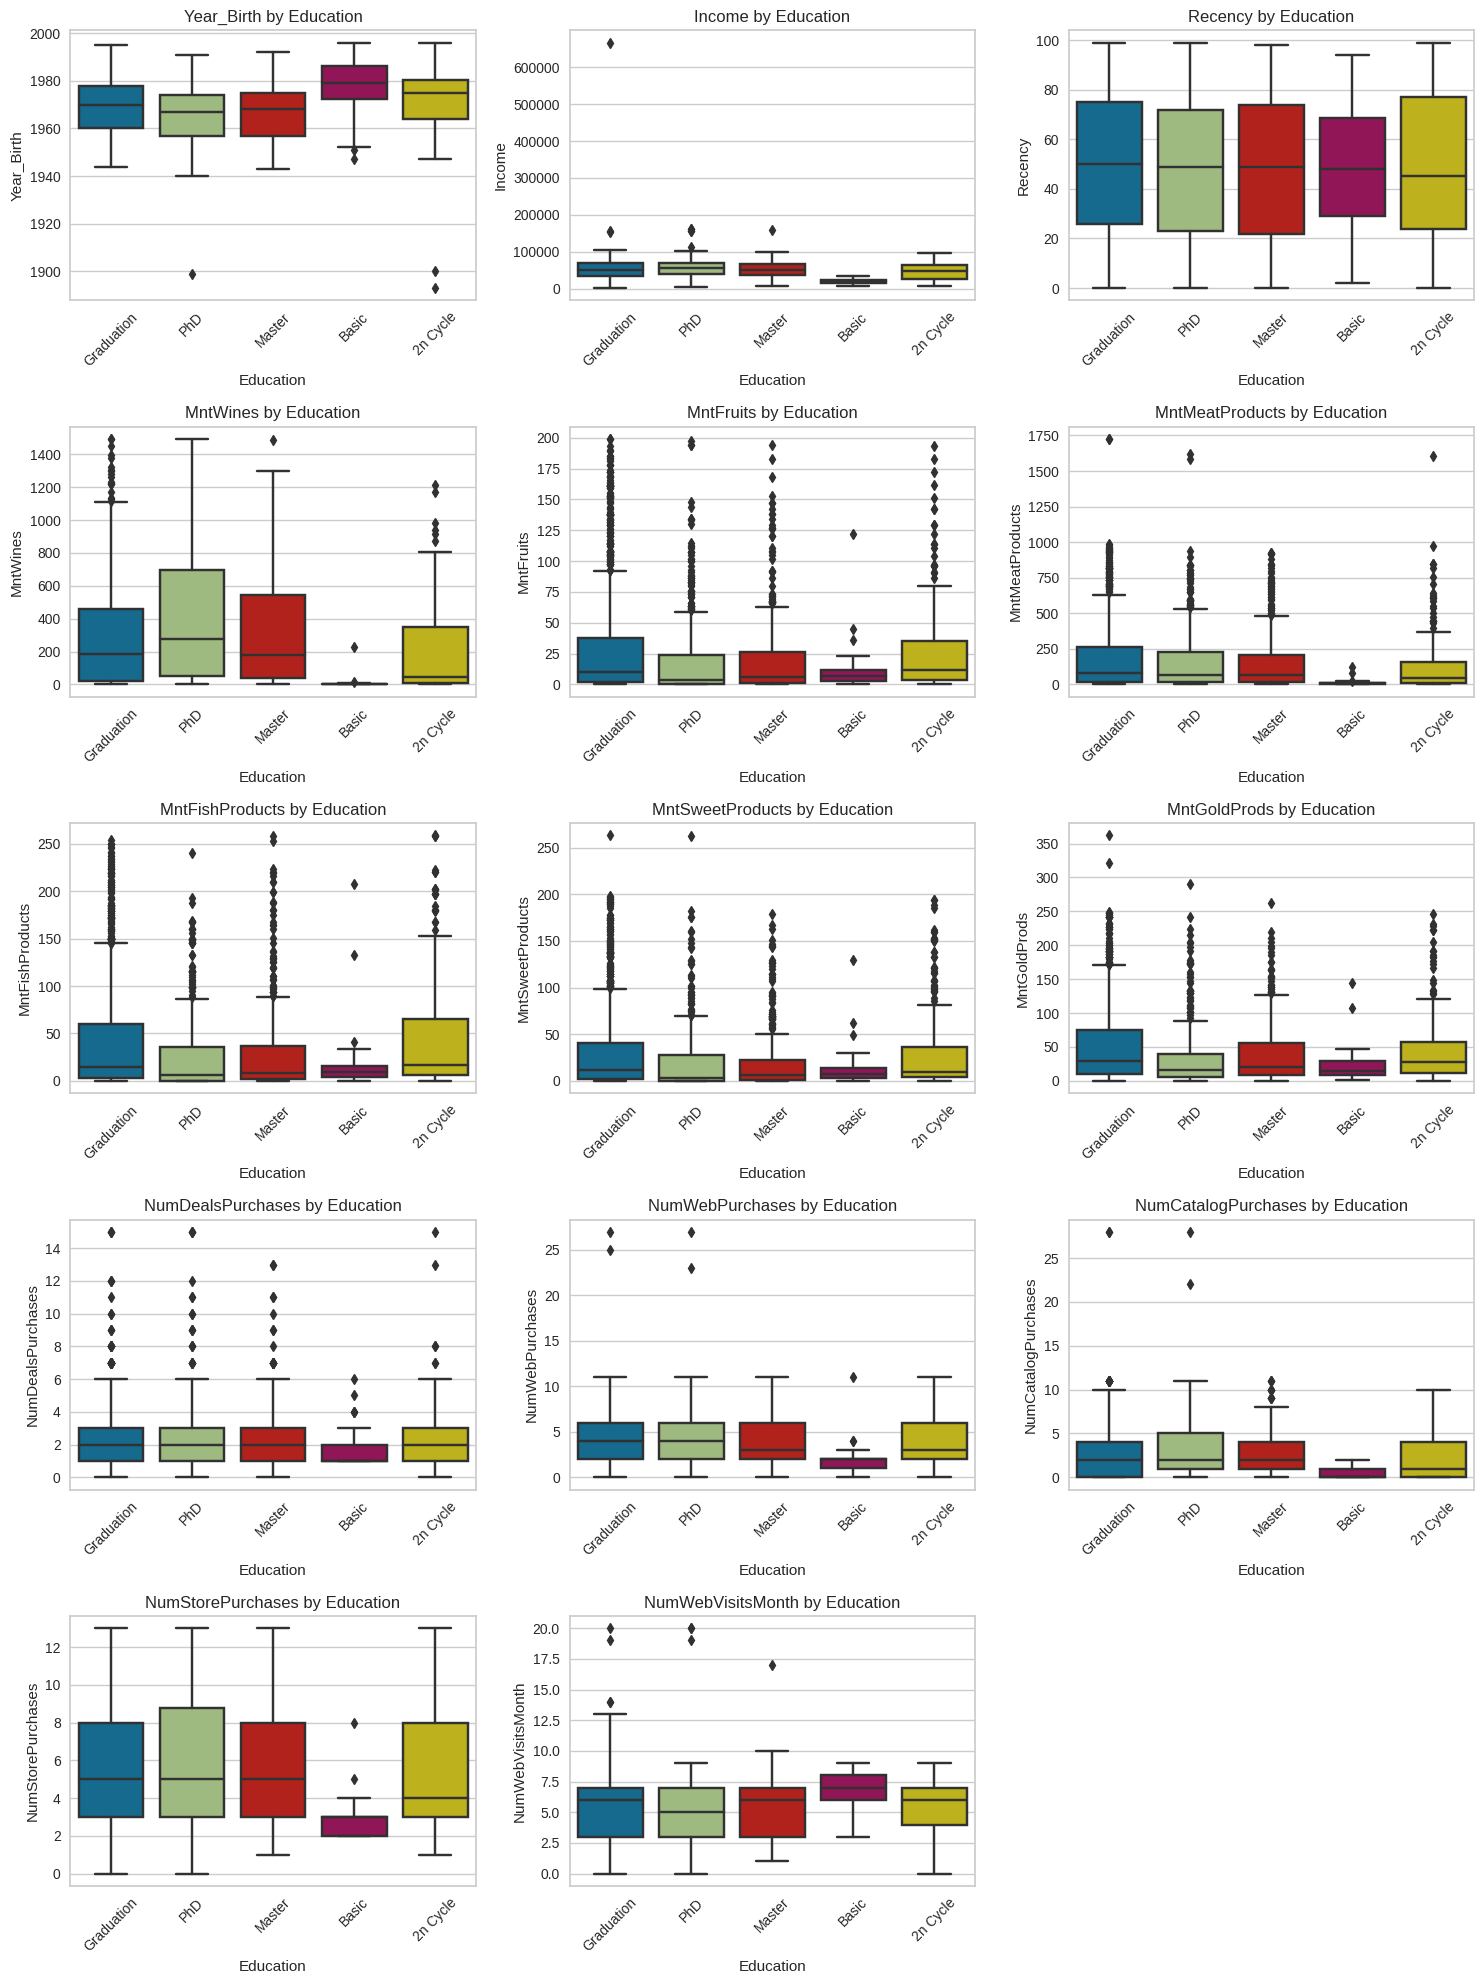

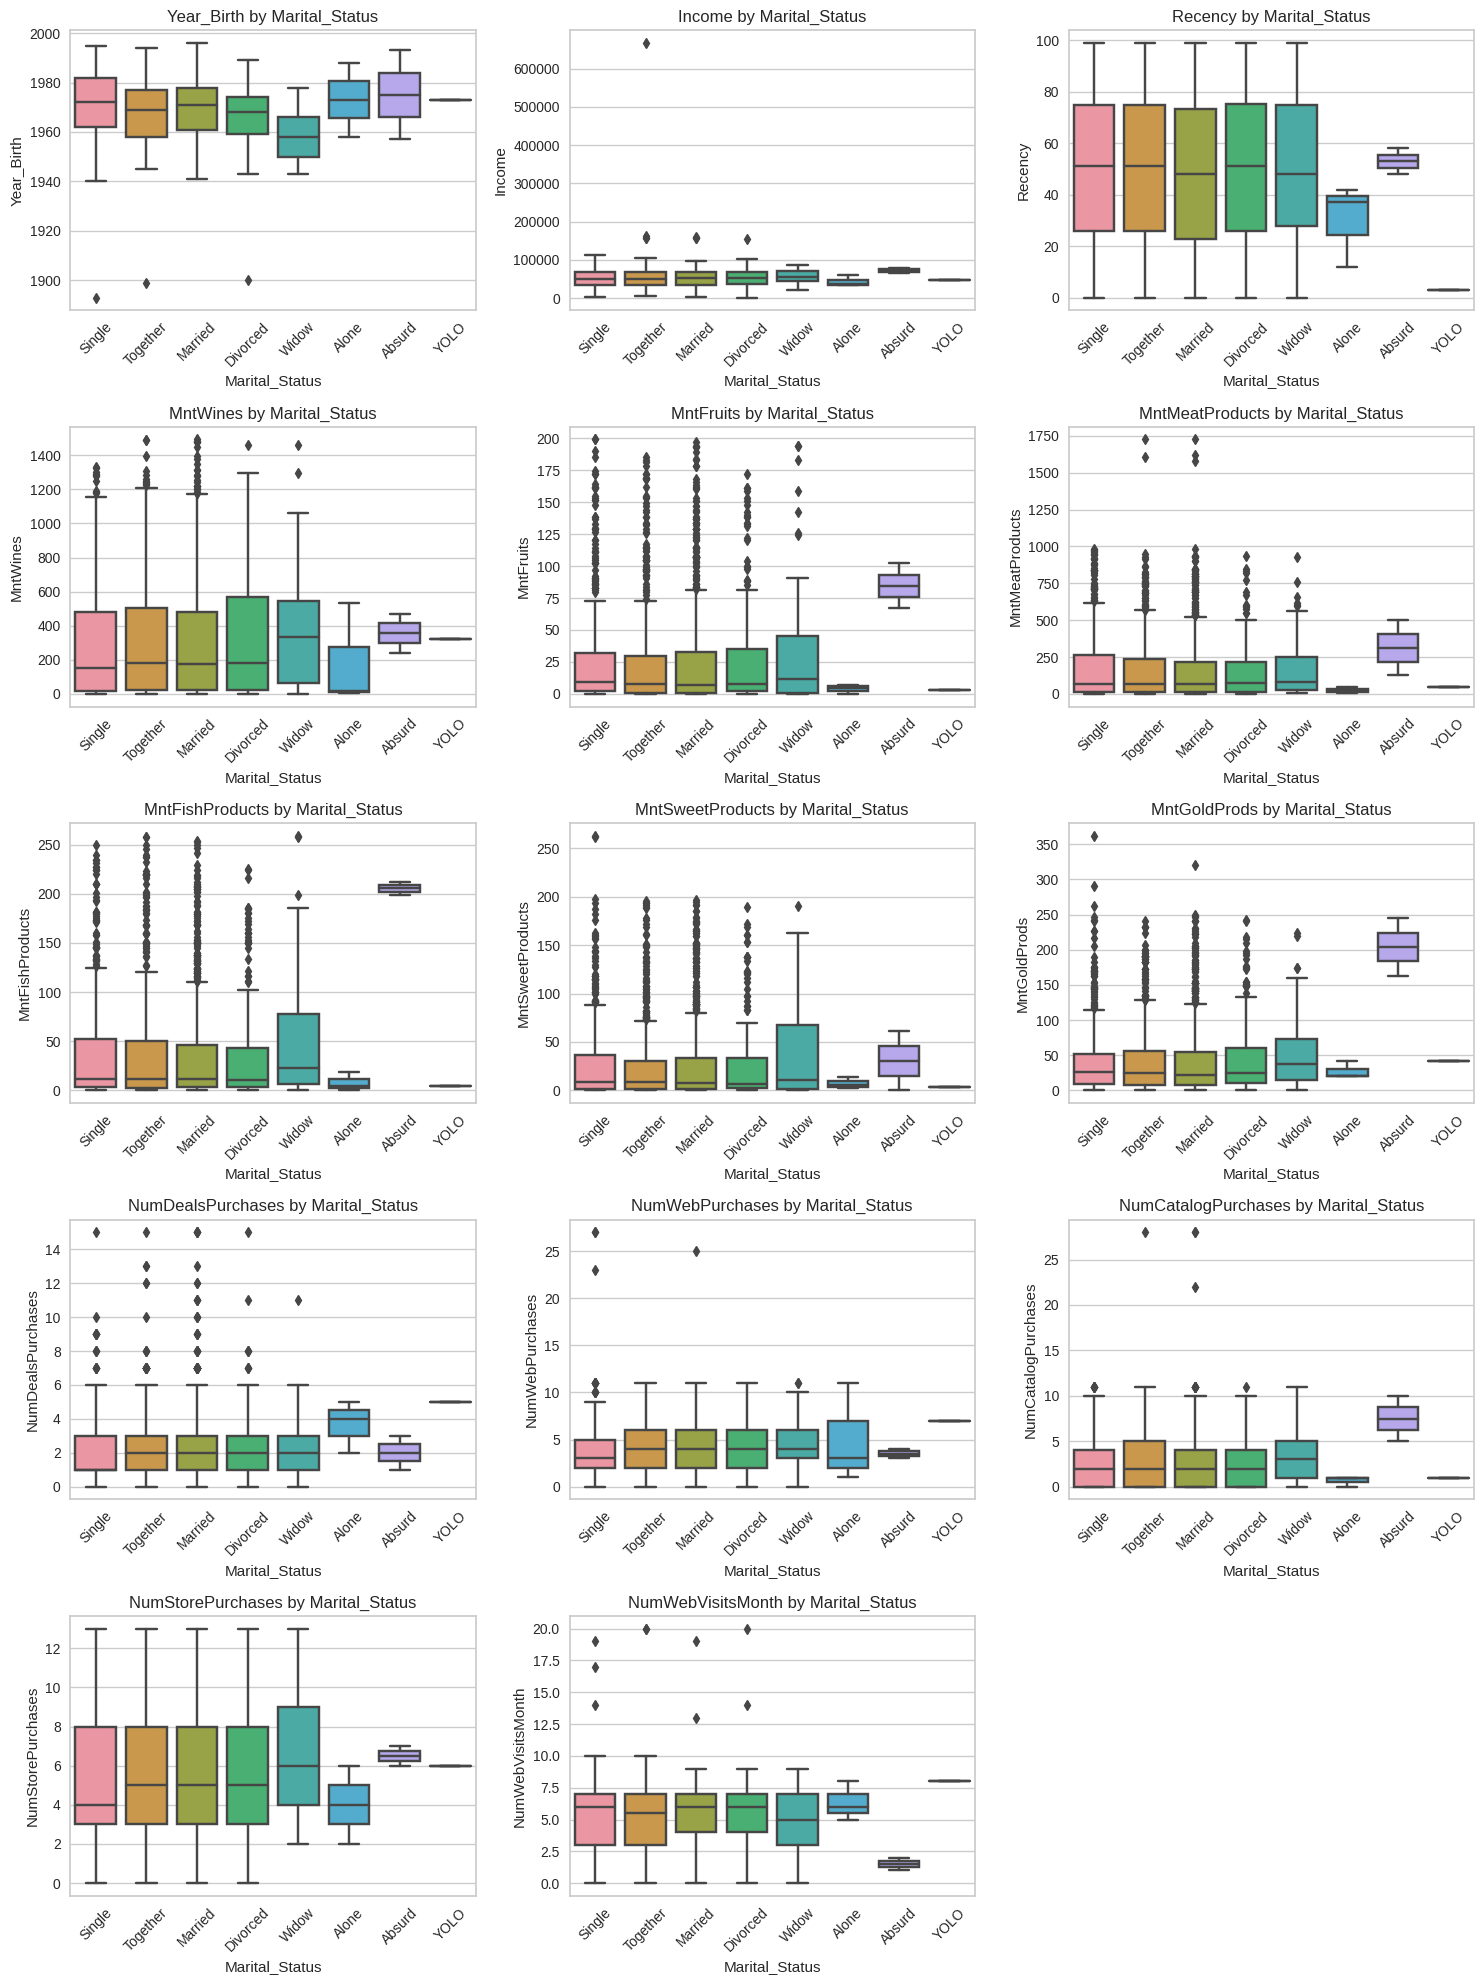

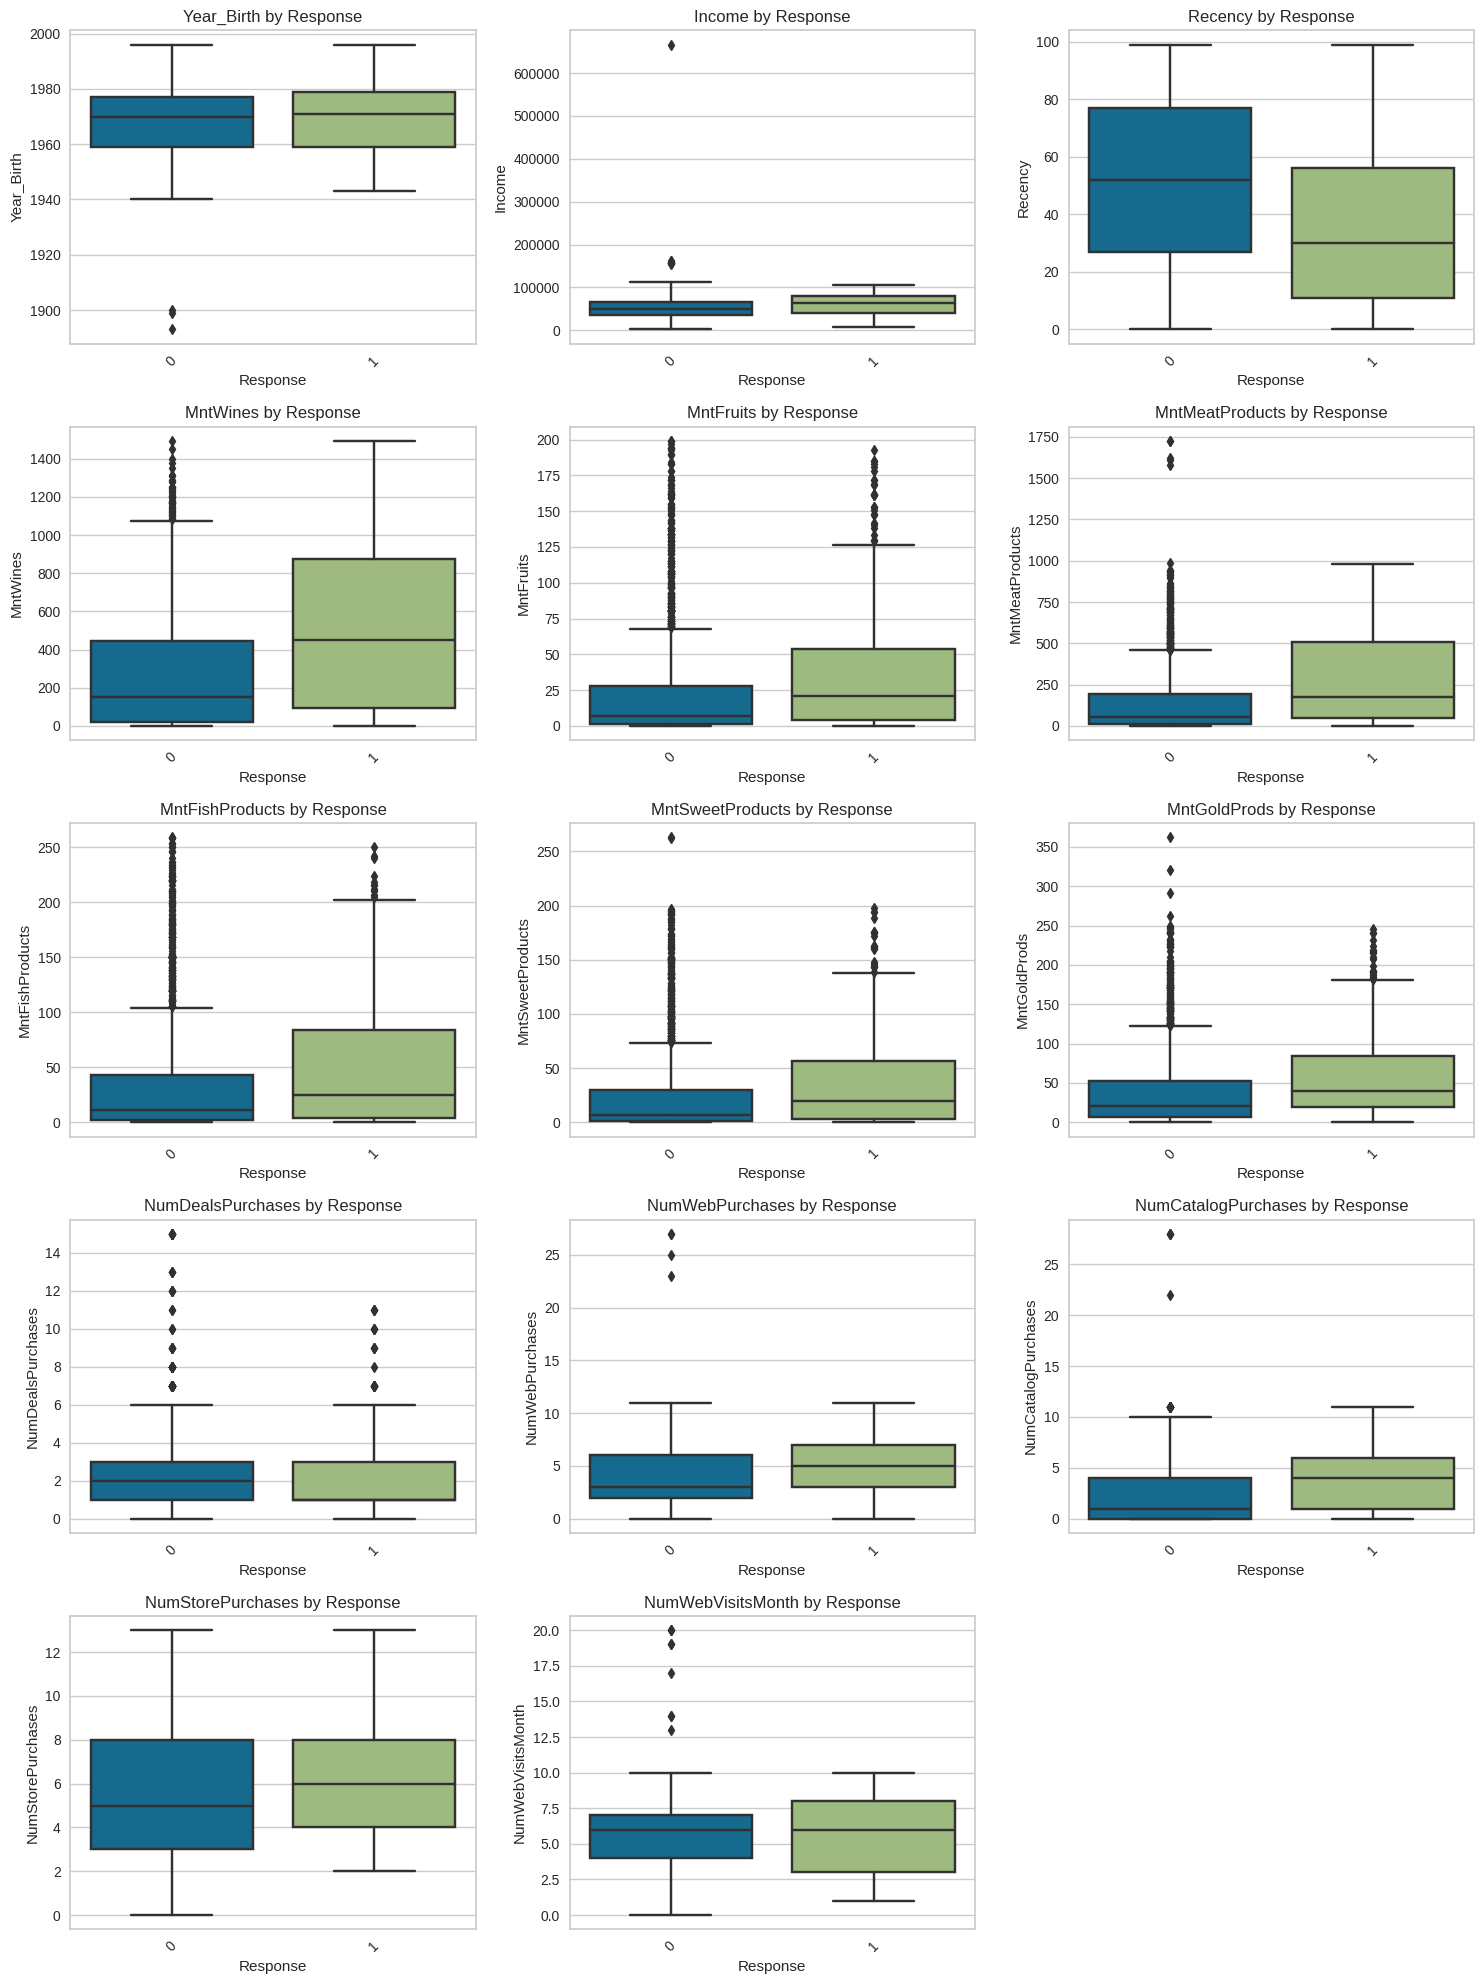

In [165]:
for cat_col in ['Education', 'Marital_Status', 'Response']:
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    for i, num_col in enumerate(numerical_cols):
        sns.boxplot(x=cat_col, y=num_col, data=df, ax=axes[i])
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

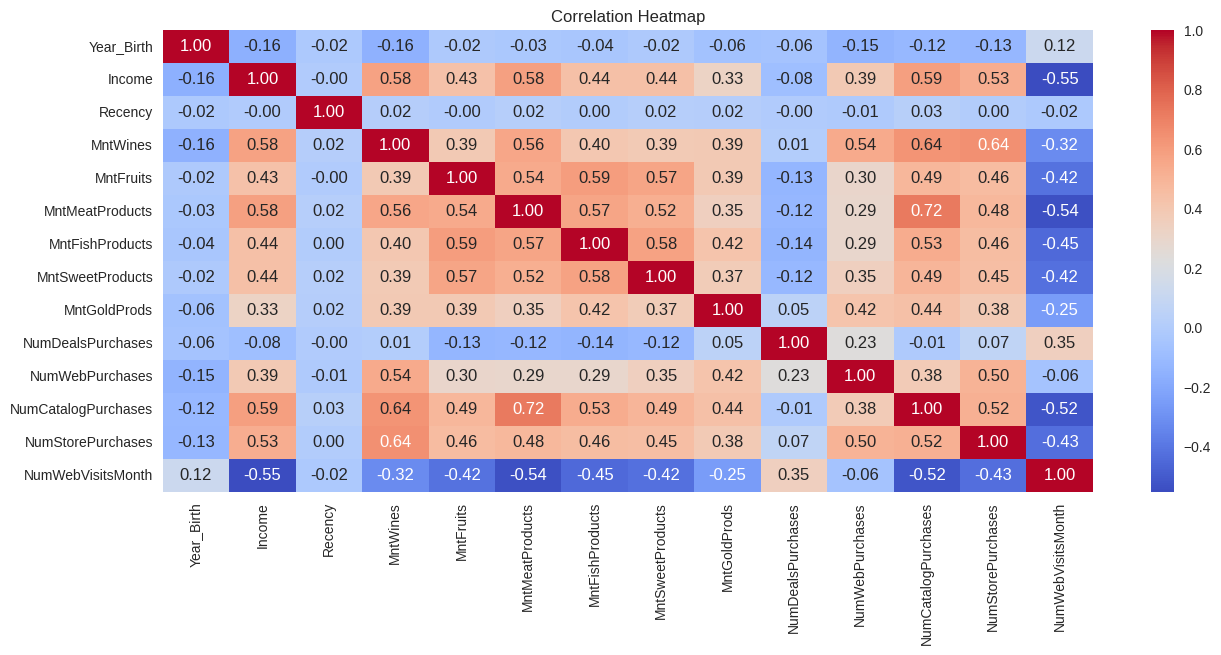

In [166]:
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

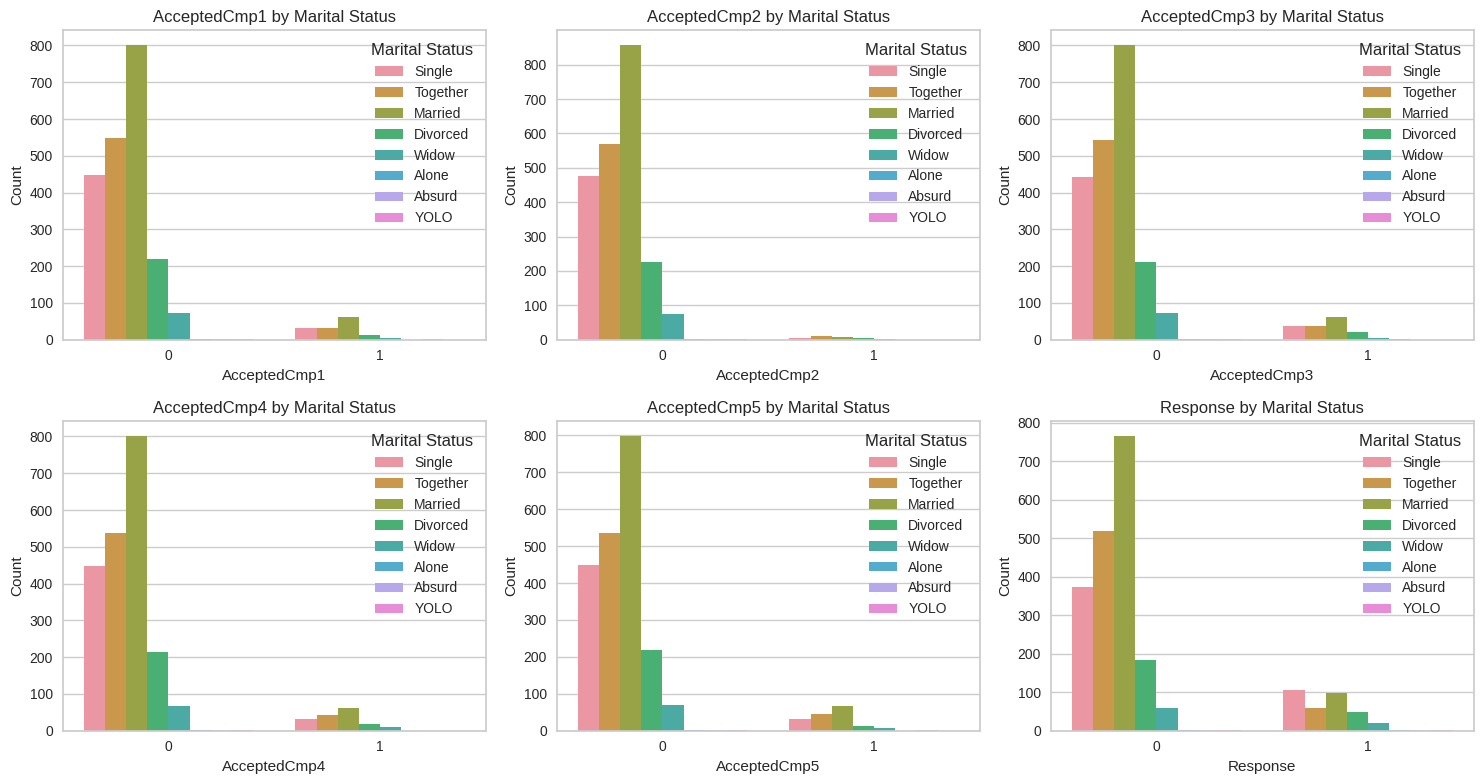

In [167]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
n_rows = (len(campaign_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, cmp in enumerate(campaign_cols):
    sns.countplot(x=cmp, hue='Marital_Status', data=df, ax=axes[i])
    axes[i].set_title(f'{cmp} by Marital Status')
    axes[i].set_xlabel(cmp)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Marital Status', loc='upper right')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


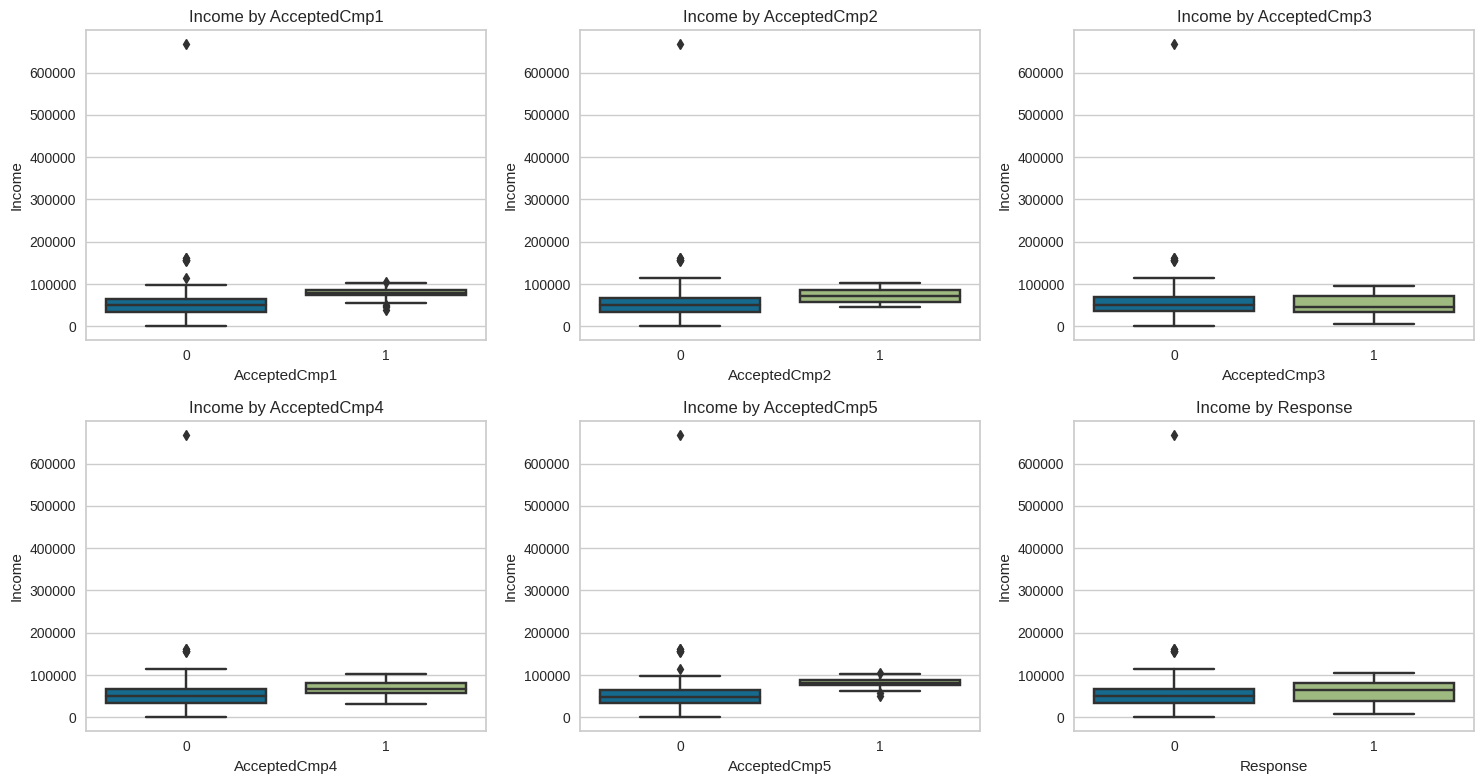

In [168]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, cmp in enumerate(campaign_cols):
    sns.boxplot(x=cmp, y='Income', data=df, ax=axes[i])
    axes[i].set_title(f'Income by {cmp}')
    axes[i].set_xlabel(cmp)
    axes[i].set_ylabel('Income')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

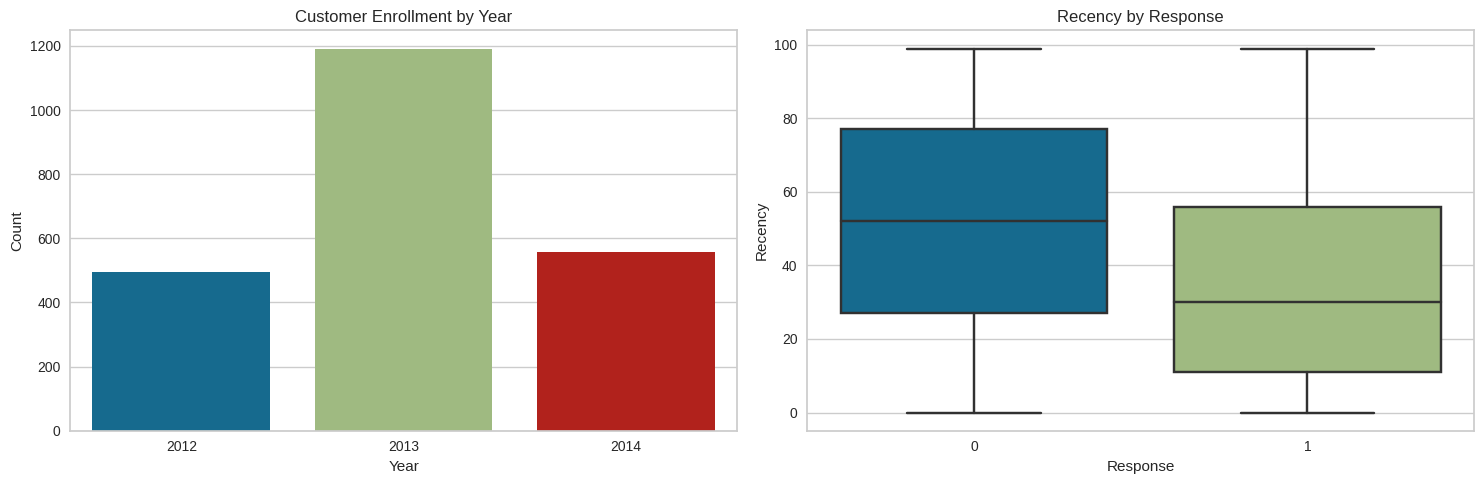

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df['Year'] = df['Dt_Customer'].dt.year
sns.countplot(x='Year', data=df, ax=axes[0])
axes[0].set_title('Customer Enrollment by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
sns.boxplot(x='Response', y='Recency', data=df, ax=axes[1])
axes[1].set_title('Recency by Response')
axes[1].set_xlabel('Response')
axes[1].set_ylabel('Recency')
plt.tight_layout()
plt.show()

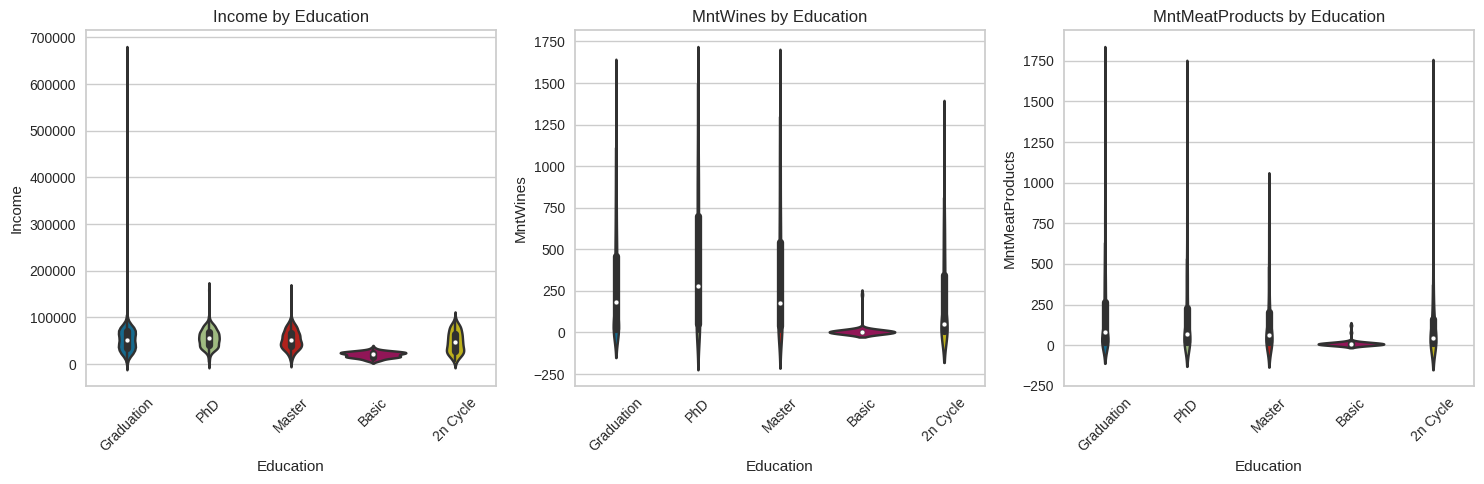

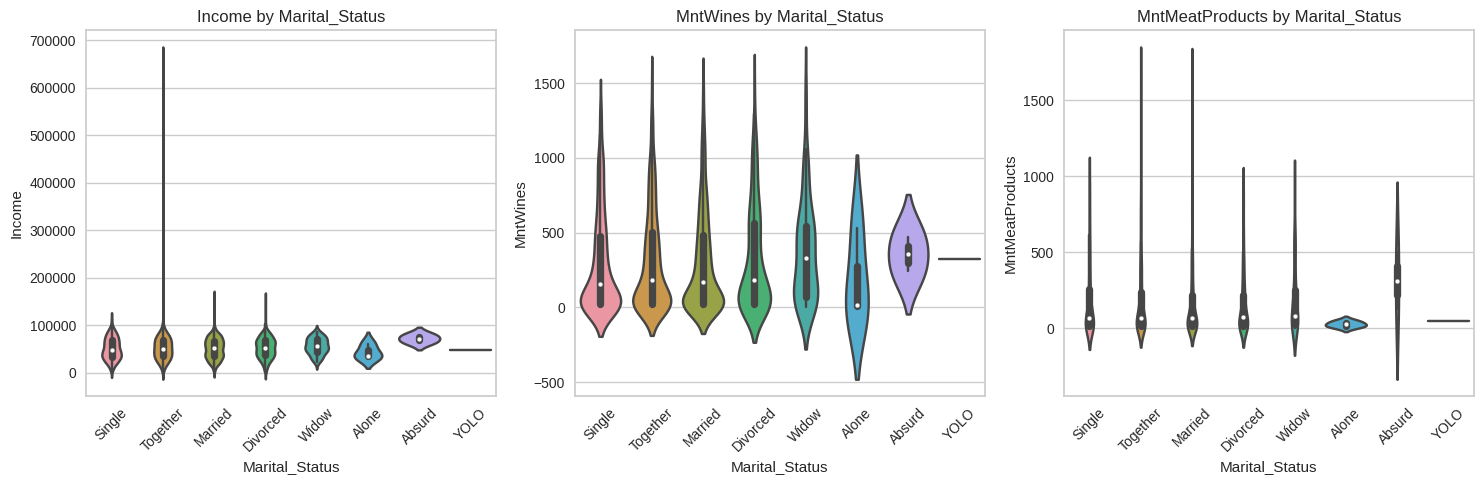

In [170]:
for cat_col in ['Education', 'Marital_Status']:
    n_rows = 1
    n_cols = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5))
    axes = axes.flatten()
    selected_num = ['Income', 'MntWines', 'MntMeatProducts']
    for i, num_col in enumerate(selected_num):
        sns.violinplot(x=cat_col, y=num_col, data=df, ax=axes[i])
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

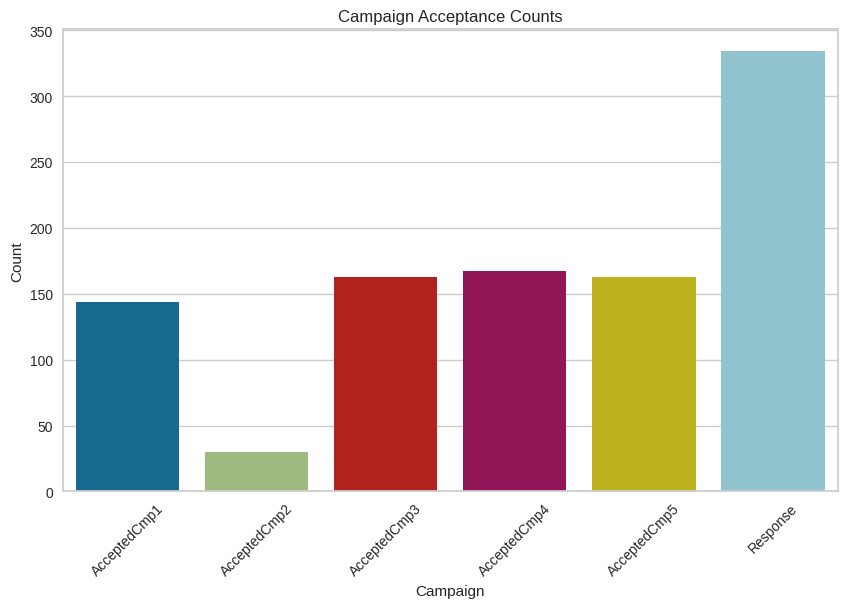

In [171]:
campaign_counts = df[campaign_cols].sum().reset_index()
campaign_counts.columns = ['Campaign', 'Count']
plt.figure(figsize=(10, 6))
sns.barplot(x='Campaign', y='Count', data=campaign_counts)
plt.title('Campaign Acceptance Counts')
plt.xlabel('Campaign')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [172]:
df=df.dropna()

In [173]:
df.drop(columns=["AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "AcceptedCmp1","AcceptedCmp2", "Complain","ID","Dt_Customer","Z_CostContact",
                "Z_Revenue","Year"],axis=1,inplace=True)

In [174]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer

le = LabelEncoder()
for col in ['Education', 'Marital_Status']:
    df[col] = le.fit_transform(df[col])


In [175]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response
0,1957,2,4,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,1
1,1954,2,4,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0
2,1965,2,5,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0
3,1984,2,5,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0
4,1981,4,3,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0


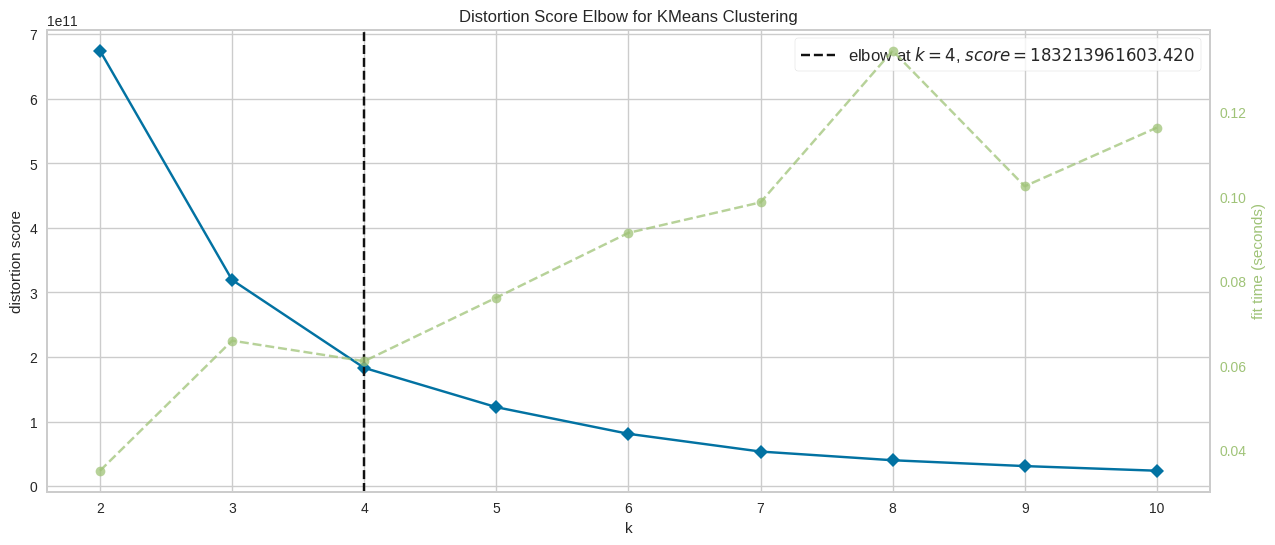

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [176]:
em = KElbowVisualizer(KMeans(), k=10)
em.fit(df)
em.show()

In [177]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

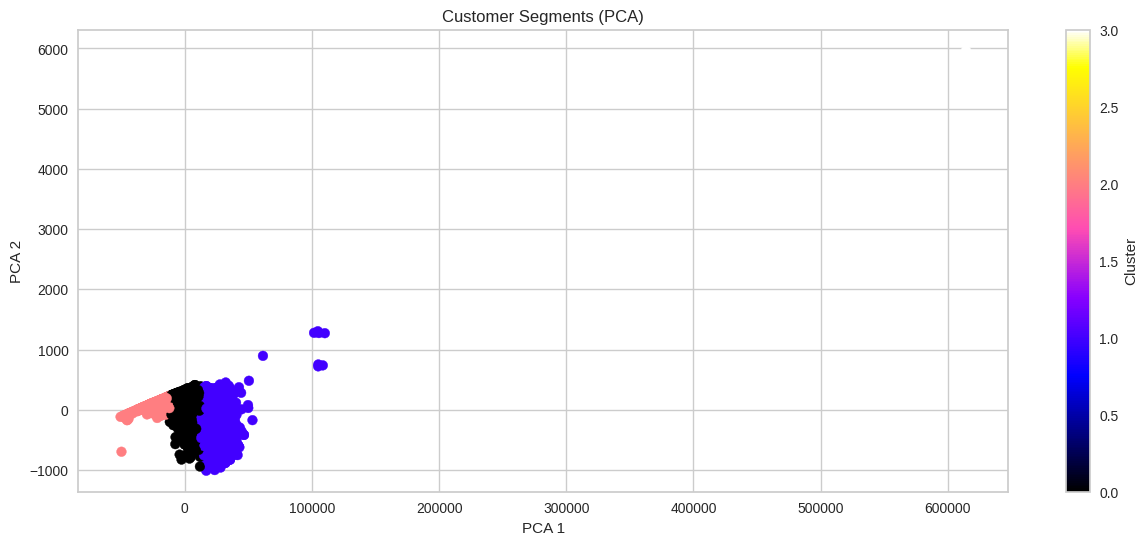

In [178]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
components = pca.fit_transform(df.drop(columns=['Cluster']))

plt.figure(figsize=(15,6))
plt.scatter(components[:, 0], components[:, 1], c=df['Cluster'], cmap='gnuplot2')
plt.title('Customer Segments (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

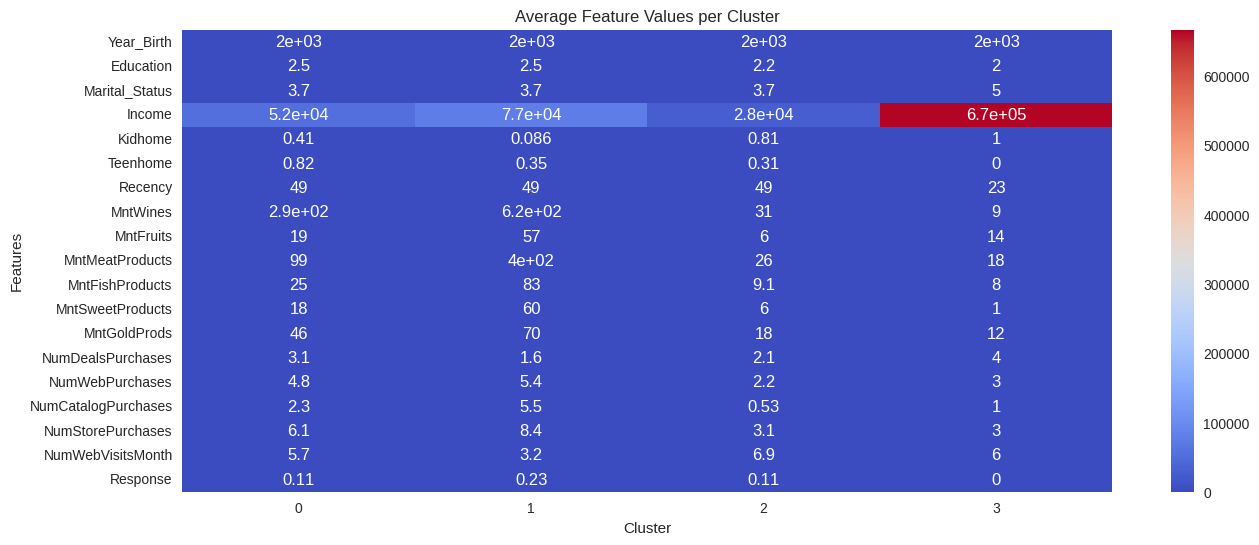

In [179]:
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)
plt.figure(figsize=(15, 6))
sns.heatmap(cluster_mean.T, annot=True, cmap='coolwarm')
plt.title('Average Feature Values per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

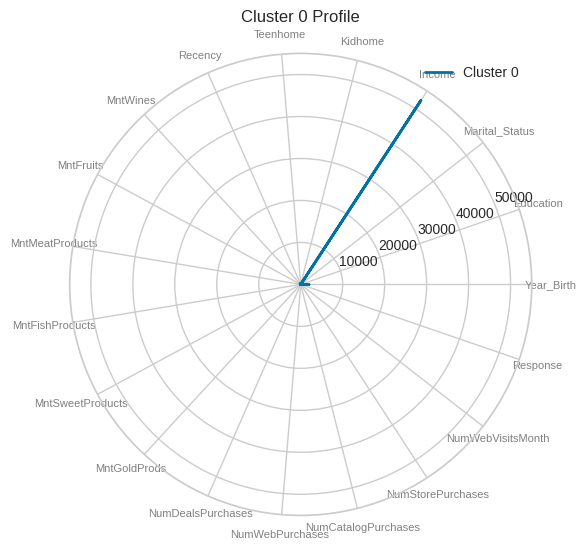

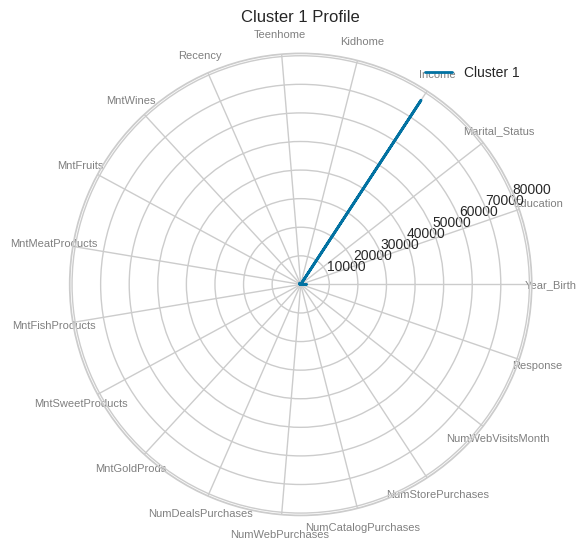

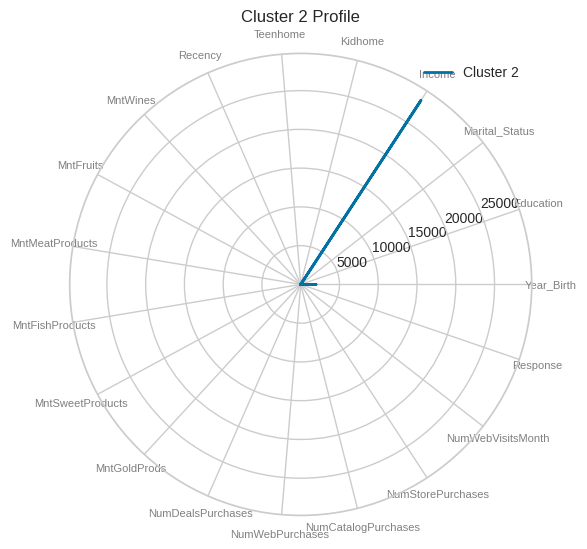

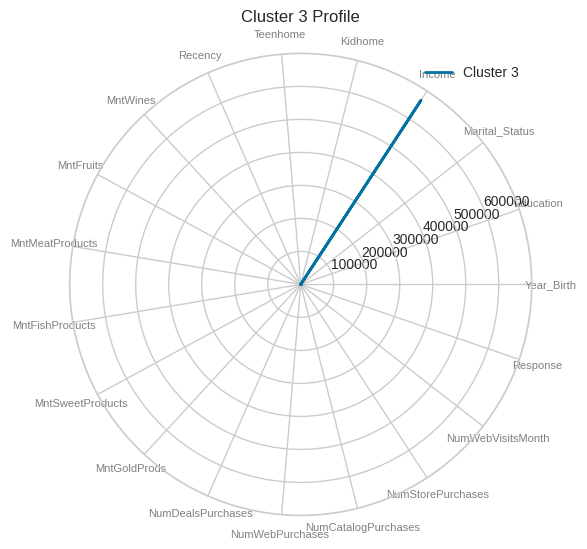

In [180]:
from math import pi

cluster_data = cluster_mean.copy()
labels = cluster_data.columns
num_vars = len(labels)

for i in range(len(cluster_data)):
    values = cluster_data.iloc[i].values.flatten().tolist()
    values += values[:1]  # repeat first to close the circle

    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]

    plt.figure(figsize=(15,6))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], labels, color='grey', size=8)
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.25)
    plt.title(f'Cluster {i} Profile')
    plt.legend()
    plt.show()

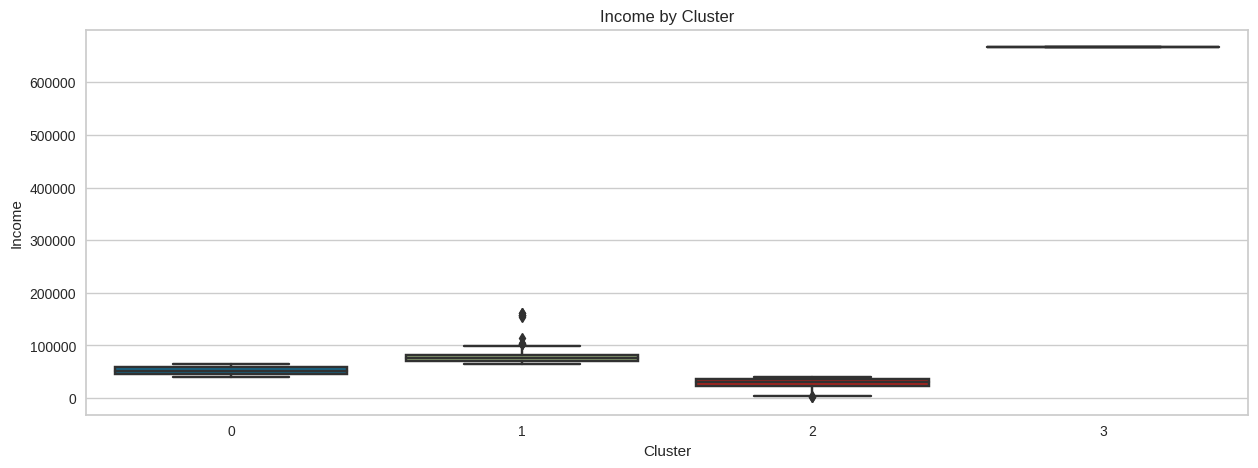

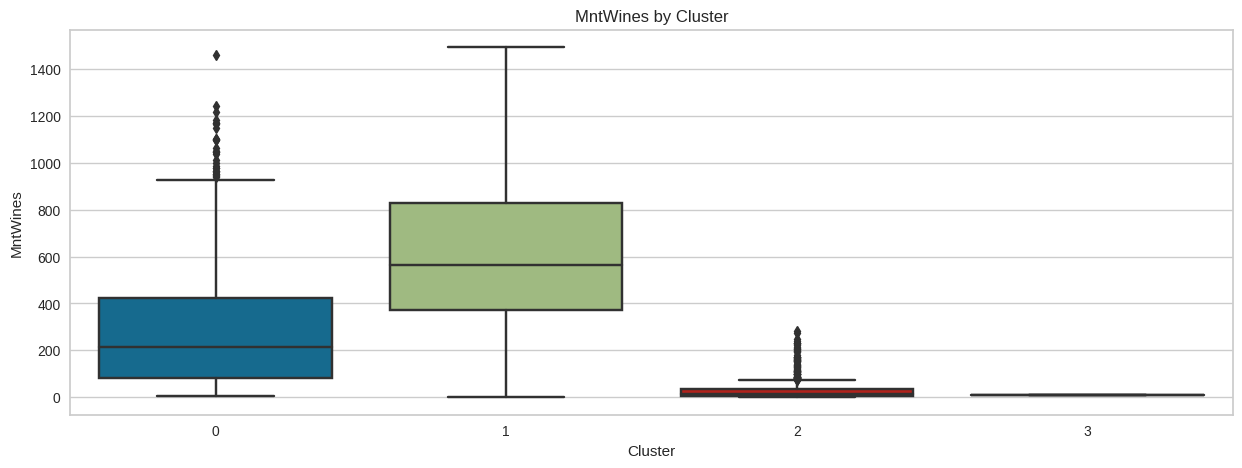

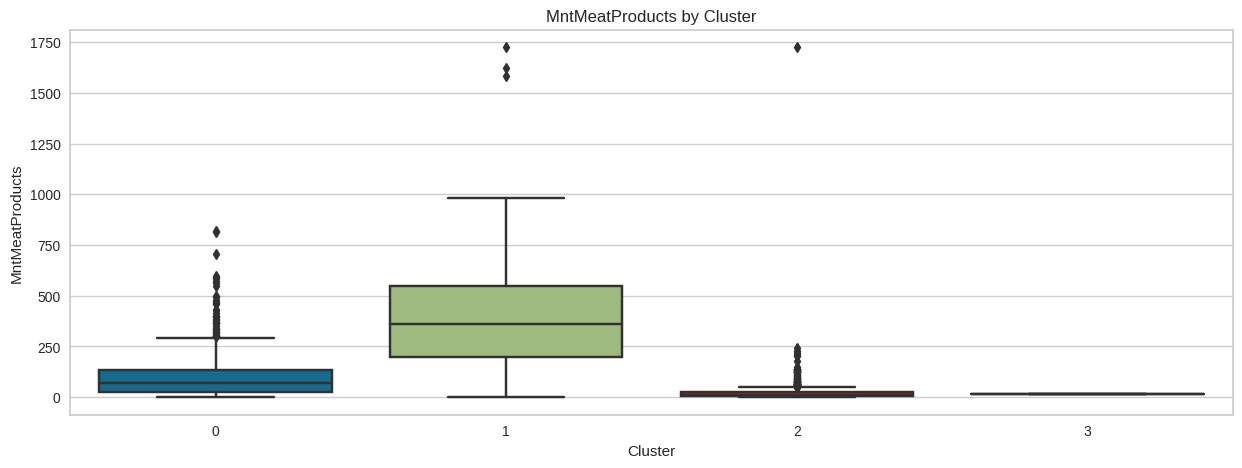

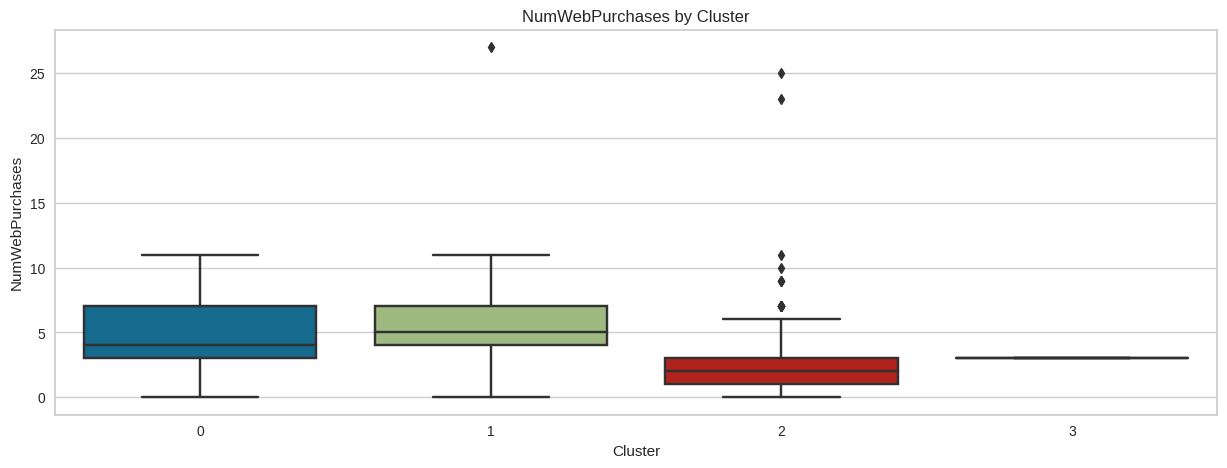

In [181]:
features = ['Income', 'MntWines', 'MntMeatProducts', 'NumWebPurchases']
for col in features:
    plt.figure(figsize=(15,5))
    sns.boxplot(x='Cluster', y=col, data=df)
    plt.title(f'{col} by Cluster')
    plt.show()

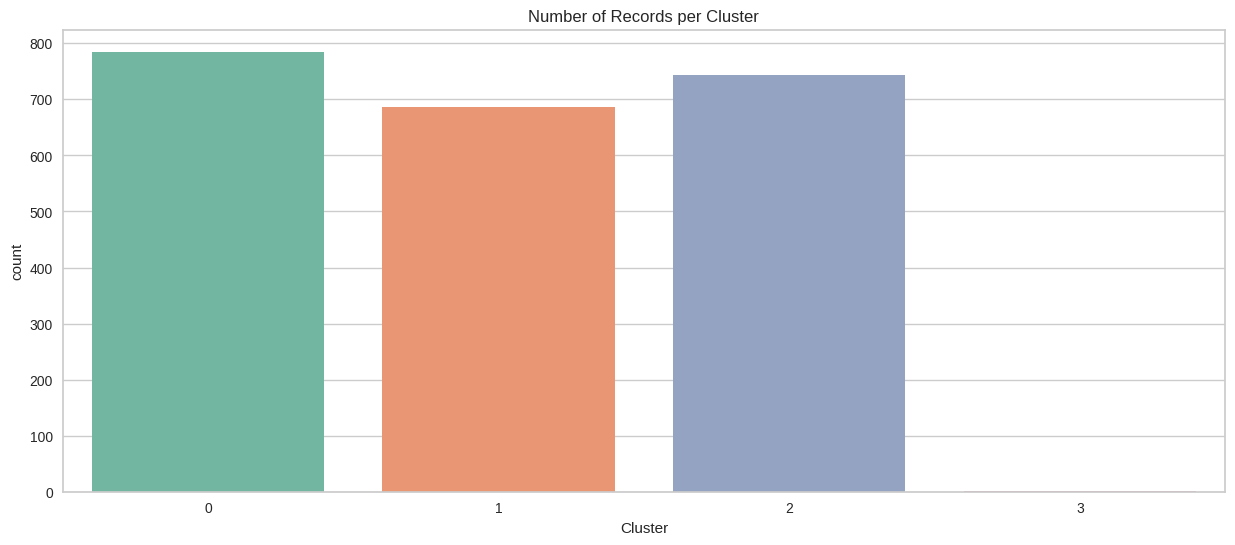

In [182]:
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title('Number of Records per Cluster')
plt.show()

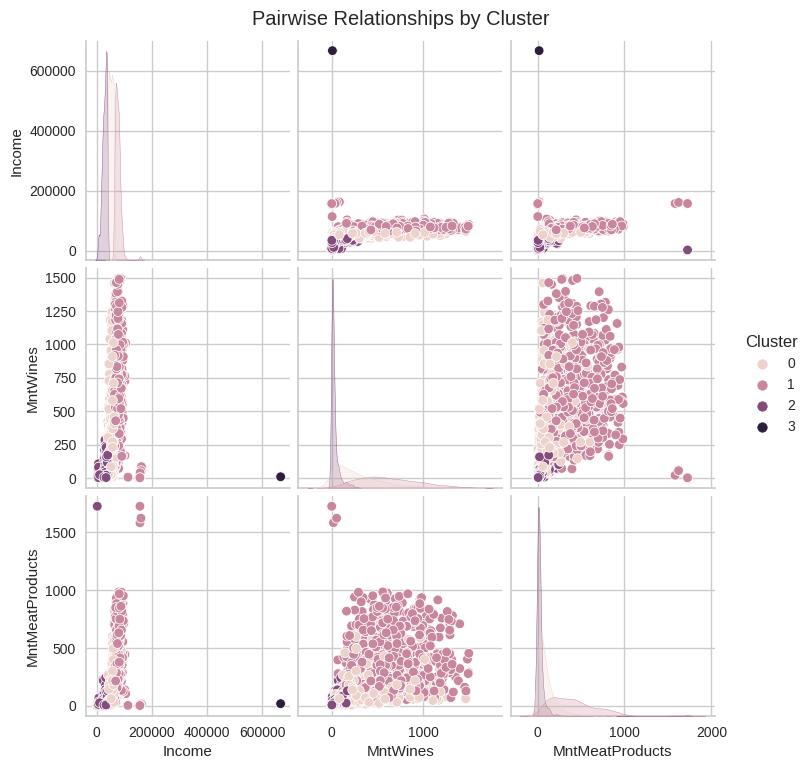

In [183]:
sns.pairplot(df, hue='Cluster', vars=['Income', 'MntWines', 'MntMeatProducts'])
plt.suptitle('Pairwise Relationships by Cluster', y=1.02)
plt.show()

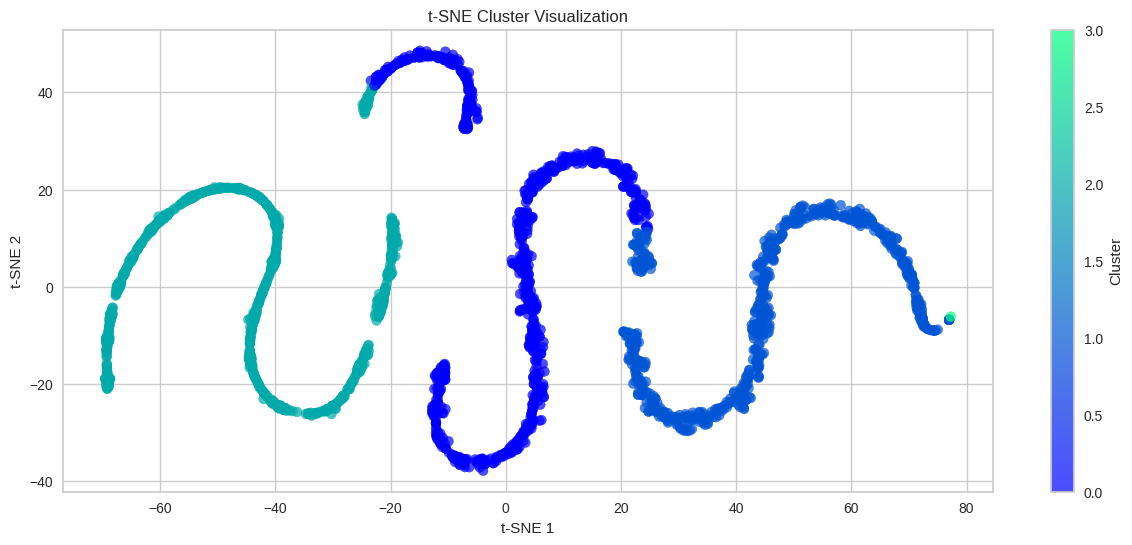

In [184]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(df)

plt.figure(figsize=(15,6))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1], c=df['Cluster'], cmap='winter', s=50, alpha=0.7)
plt.title('t-SNE Cluster Visualization')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.show()